# 2D Ising Model: Burn-In, Sampling and Magnetisation Traces
This notebook extends my single-spin Metropolis update and Monte Carlo sweep into a complete fixed-temperature simulation loop.
It separates burn-in from production sampling, records the signed magnetisation trace, saves reproducible outputs and estimates the effect of autocorrelation.

Throughout the notebook, the simulation uses $J=1$, $k_B=1$, $B=0$ and periodic boundary conditions. One Monte Carlo sweep is defined here as $L^2$ random single-spin flip attempts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Keeping every figure and data file from this notebook in one location.
OUTPUT_DIR = Path("outputs/day21")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Initial Conditions and Magnetisation
**Source:** Krauth, *Statistical Mechanics: Algorithms and Computations*, pp. 7–9 (Algorithms 1.2–1.3 and the discussion of initial conditions and correlation time).

A Markov chain must start from an initial configuration, but that configuration is not generally an equilibrium sample at the target temperature. The code therefore supports random, all-up and all-down starts. The signed magnetisation per spin is

$$m = \frac{1}{L^2}\sum_i s_i,$$

which preserves information about whether the chain occupies the positive or negative magnetisation sector.Explicit burn-in and production phases

In [2]:
def initialise_grid(
    L: int,
    rng: np.random.Generator,
    mode: str = "random",
) -> np.ndarray:
    """Create an L x L lattice containing only -1 and +1 spins."""
    # The lattice must contain at least four sites for a meaningful square model.
    if L < 2:
        raise ValueError("L must be at least 2.")

    # A random start resembles a high-temperature, disordered configuration.
    if mode == "random":
        return rng.choice((-1, 1), size=(L, L)).astype(np.int8)

    # Ordered starts are useful for testing whether the chain forgets its initial state.
    if mode == "up":
        return np.ones((L, L), dtype=np.int8)

    if mode == "down":
        return -np.ones((L, L), dtype=np.int8)

    raise ValueError("mode must be 'random', 'up', or 'down'.")


def calculate_magnetisation(grid: np.ndarray) -> float:
    """Return the signed magnetisation per spin."""
    # np.mean(grid) is exactly sum(s_i) / L^2 for a square spin lattice.
    return float(np.mean(grid))

## 2. The Core Engine: Local Ising Metropolis Update
**Source:** Krauth, p. 250, Fig. 5.14 and Algorithm 5.7 (`markov-ising`).

For a proposed flip of spin $s_i$, the local energy change is

$$\Delta E = 2J s_i \sum_{j\in\mathrm{nn}(i)} s_j.$$

The move is accepted with probability $\min\left(1,e^{-\Delta E/T}\right)$ because $k_B=1$. Krauth specifically warns that factors of two should be checked on small lattices before larger simulations are trusted.Plot and save each trace

In [3]:
def local_energy_change(
    grid: np.ndarray,
    i: int,
    j: int,
    J: float = 1.0,
) -> float:
    """Return the energy change produced by flipping grid[i, j]."""
    L = grid.shape[0]
    spin = int(grid[i, j])

    # Modulo arithmetic enforces periodic boundary conditions in both directions.
    neighbour_sum = (
        int(grid[(i - 1) % L, j]) +  # Above
        int(grid[(i + 1) % L, j]) +  # Below
        int(grid[i, (j - 1) % L]) +  # Left
        int(grid[i, (j + 1) % L])    # Right
    )

    # Flipping s_i reverses all four bonds connected to that spin.
    return 2.0 * J * spin * neighbour_sum


def attempted_spin_flip(
    grid: np.ndarray,
    i: int,
    j: int,
    T: float,
    rng: np.random.Generator,
    J: float = 1.0,
) -> bool:
    """Attempt one local Metropolis spin flip and report whether it was accepted."""
    if T <= 0.0:
        raise ValueError("T must be positive.")

    # Calculate the local energy cost before changing the lattice.
    delta_E = local_energy_change(grid, i, j, J)

    # Energy-lowering and energy-neutral moves are accepted automatically.
    if delta_E <= 0.0:
        grid[i, j] *= -1
        return True

    # Energy-raising moves are accepted according to the Boltzmann factor.
    acceptance_probability = np.exp(-delta_E / T)
    if rng.random() < acceptance_probability:
        grid[i, j] *= -1
        return True

    # A rejected move leaves the lattice unchanged.
    return False

## 3. The Monte Carlo Sweep
**Source:** Krauth, p. 250, Algorithm 5.7, for random-site single-spin updates.

Krauth's elementary update selects one random site and attempts one spin flip. In this notebook, one Monte Carlo sweep groups $L^2$ such attempts, so every site is selected once *on average*. Random selection means that some sites may be chosen more than once and others not at all during an individual sweep.Run the four required diagnostics

In [4]:
def metropolis_sweep(
    grid: np.ndarray,
    T: float,
    rng: np.random.Generator,
    J: float = 1.0,
) -> float:
    """Perform L^2 random attempted flips and return the acceptance fraction."""
    # Prevent accidental use of a non-square array.
    if grid.ndim != 2 or grid.shape[0] != grid.shape[1]:
        raise ValueError("grid must be a square two-dimensional array.")

    L = grid.shape[0]
    accepted = 0

    # One sweep contains exactly one attempted update per site on average.
    for _ in range(grid.size):
        i = int(rng.integers(0, L))
        j = int(rng.integers(0, L))

        # bool is converted to 1 for an accepted move and 0 for a rejected move.
        accepted += int(attempted_spin_flip(grid, i, j, T, rng, J))

    # The acceptance fraction is a useful diagnostic of temperature-dependent dynamics.
    return accepted / grid.size

## 4. Burn-In and Production Sampling
**Source:** Krauth, pp. 7–9, for the memory of the starting configuration and the role of correlation time in Markov-chain sampling.

The burn-in trace is retained for diagnosis but excluded from equilibrium averages. After burn-in, the production phase records the signed magnetisation and acceptance fraction after every sweep. `sample_interval` creates a storage-strided copy only; it does **not** prove that the retained values are statistically independent.

In [5]:
def run_magnetisation_trace(
    L: int,
    T: float,
    n_burn_sweeps: int,
    n_production_sweeps: int,
    sample_interval: int = 1,
    seed: int = 0,
    initial_state: str = "random",
    J: float = 1.0,
) -> dict:
    """Run one reproducible fixed-temperature Ising simulation."""
    # Validate all loop controls before allocating arrays.
    if n_burn_sweeps < 0:
        raise ValueError("n_burn_sweeps must be non-negative.")

    if n_production_sweeps < 1:
        raise ValueError("n_production_sweeps must be positive.")

    if sample_interval < 1:
        raise ValueError("sample_interval must be at least 1.")

    # A local Generator makes the entire trajectory reproducible from the seed.
    rng = np.random.default_rng(seed)
    grid = initialise_grid(L, rng, initial_state)
    initial_grid = grid.copy()

    # Burn-in includes the initial state at sweep zero for trace plotting.
    burn_m = np.empty(n_burn_sweeps + 1, dtype=float)
    burn_acceptance = np.empty(n_burn_sweeps, dtype=float)
    burn_m[0] = calculate_magnetisation(grid)

    # These values diagnose relaxation but are not used in production averages.
    for sweep in range(n_burn_sweeps):
        burn_acceptance[sweep] = metropolis_sweep(grid, T, rng, J)
        burn_m[sweep + 1] = calculate_magnetisation(grid)

    # Production measurements begin only after the complete burn-in period.
    production_m = np.empty(n_production_sweeps, dtype=float)
    production_acceptance = np.empty(n_production_sweeps, dtype=float)

    for sweep in range(n_production_sweeps):
        production_acceptance[sweep] = metropolis_sweep(grid, T, rng, J)
        production_m[sweep] = calculate_magnetisation(grid)

    # This is a storage stride, not an assertion that samples are independent.
    saved_m = production_m[::sample_interval].copy()

    return {
        "L": L,
        "T": T,
        "J": J,
        "seed": seed,
        "initial_state": initial_state,
        "n_burn_sweeps": n_burn_sweeps,
        "n_production_sweeps": n_production_sweeps,
        "sample_interval": sample_interval,
        "initial_grid": initial_grid,
        "burn_m": burn_m,
        "burn_acceptance": burn_acceptance,
        "production_m": production_m,
        "production_acceptance": production_acceptance,
        "saved_m": saved_m,
        # Only production values contribute to the reported averages.
        "mean_m": float(np.mean(production_m)),
        "mean_abs_m": float(np.mean(np.abs(production_m))),
        "mean_acceptance": float(np.mean(production_acceptance)),
        "final_grid": grid.copy(),
    }

## 5. Trace Plotting and Reproducible Output
**Source:** Krauth, p. 251, Fig. 5.15, for diagnosing local Ising dynamics through a magnetisation trajectory.

The trace plot shows the initial condition, the entire burn-in period and the production trajectory on one axis. A vertical line marks the boundary between the last burn-in measurement and the first production measurement. Each run also saves its parameters, random seed, traces, acceptance histories and lattice configurations.Autocorrelation and rough effective sample size

In [6]:
def make_run_tag(run: dict) -> str:
    """Create a filename-safe identifier from the run parameters."""
    temperature_tag = f"{run['T']:.3f}".replace(".", "p")

    return (
        f"L{run['L']}_T{temperature_tag}_"
        f"{run['initial_state']}_seed{run['seed']}"
    )


def plot_magnetisation_trace(run: dict) -> Path:
    """Plot and save the complete burn-in plus production magnetisation trace."""
    burn_m = np.asarray(run["burn_m"])
    production_m = np.asarray(run["production_m"])

    # The initial configuration is sweep 0; production begins after the final burn-in point.
    full_trace = np.concatenate((burn_m, production_m))
    sweep_number = np.arange(full_trace.size)
    burn_boundary = burn_m.size - 0.5

    plt.figure(figsize=(10, 5))
    plt.plot(
        sweep_number,
        full_trace,
        linewidth=0.8,
        label="signed magnetisation",
    )
    plt.axvline(
        burn_boundary,
        linestyle="--",
        label="burn-in / production boundary",
    )
    plt.axhline(0.0, linewidth=0.8)

    # Magnetisation per spin must remain inside its physical range [-1, 1].
    plt.ylim(-1.05, 1.05)
    plt.xlabel("Monte Carlo sweep")
    plt.ylabel("Magnetisation per spin, m")
    plt.title(
        f"2D Ising magnetisation trace: "
        f"L={run['L']}, T={run['T']}, "
        f"start={run['initial_state']}, seed={run['seed']}"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Save a publication-ready raster copy while keeping the plot visible in Jupyter.
    figure_path = OUTPUT_DIR / f"trace_{make_run_tag(run)}.png"
    plt.savefig(figure_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    return figure_path


def save_trace_data(run: dict) -> Path:
    """Save the run parameters and raw arrays in a compressed NumPy archive."""
    data_path = OUTPUT_DIR / f"trace_{make_run_tag(run)}.npz"

    np.savez_compressed(
        data_path,
        L=run["L"],
        T=run["T"],
        J=run["J"],
        seed=run["seed"],
        initial_state=run["initial_state"],
        n_burn_sweeps=run["n_burn_sweeps"],
        n_production_sweeps=run["n_production_sweeps"],
        sample_interval=run["sample_interval"],
        initial_grid=run["initial_grid"],
        burn_m=run["burn_m"],
        burn_acceptance=run["burn_acceptance"],
        production_m=run["production_m"],
        production_acceptance=run["production_acceptance"],
        saved_m=run["saved_m"],
        mean_m=run["mean_m"],
        mean_abs_m=run["mean_abs_m"],
        mean_acceptance=run["mean_acceptance"],
        final_grid=run["final_grid"],
    )

    return data_path

## 6. Required Diagnostic Runs
**Source:** Krauth, pp. 250–252, especially Figs. 5.15–5.17. Page 250 gives the exact two-dimensional critical benchmark as $\beta_c=\log(1+\sqrt{2})/2\approx0.4407$, corresponding to $T_c\approx2.269$ in the units used here.

The four runs test ordered low-temperature behaviour, loss of order at high temperature and sensitivity to different initial conditions near the critical region.generate your diagnostic summary

Running low_ordered...


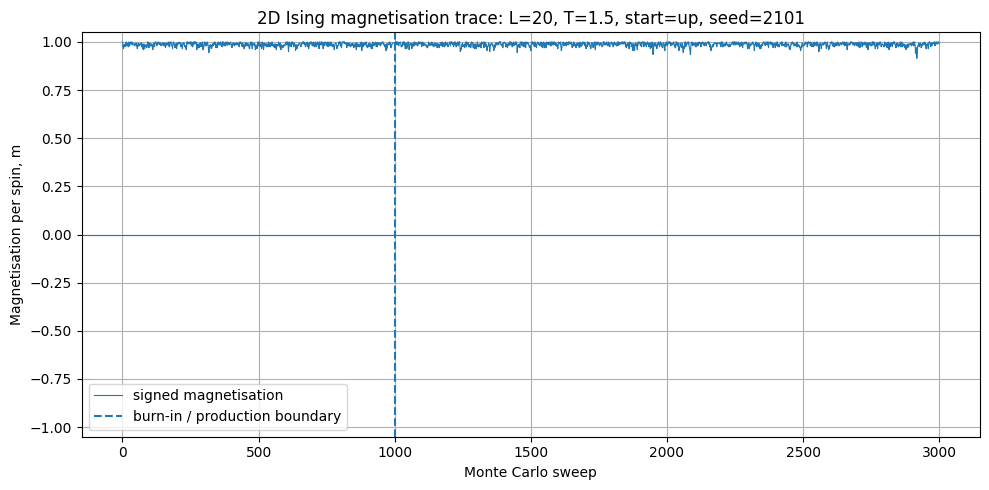

  mean m       = 0.9868
  mean |m|     = 0.9868
  acceptance   = 0.0130
  figure saved = outputs\day21\trace_L20_T1p500_up_seed2101.png
  data saved   = outputs\day21\trace_L20_T1p500_up_seed2101.npz

Running critical_random...


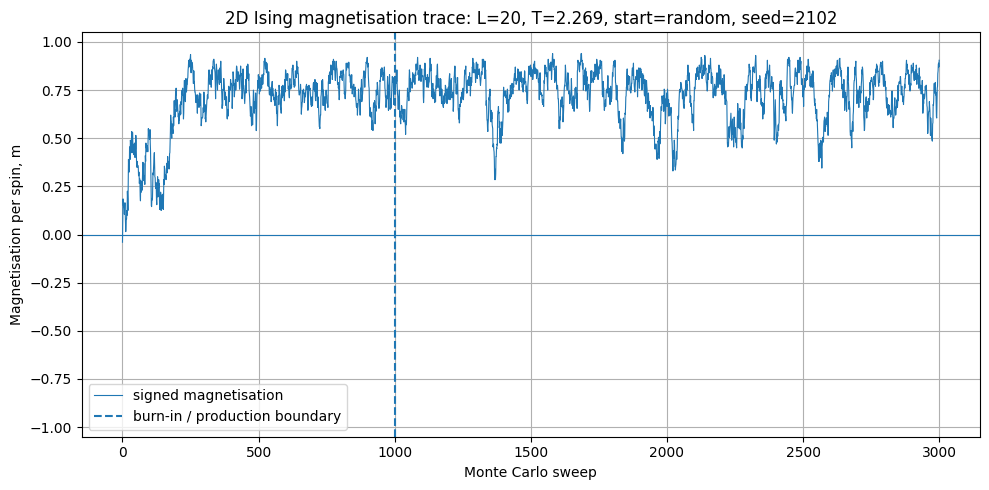

  mean m       = 0.7357
  mean |m|     = 0.7357
  acceptance   = 0.1822
  figure saved = outputs\day21\trace_L20_T2p269_random_seed2102.png
  data saved   = outputs\day21\trace_L20_T2p269_random_seed2102.npz

Running critical_ordered...


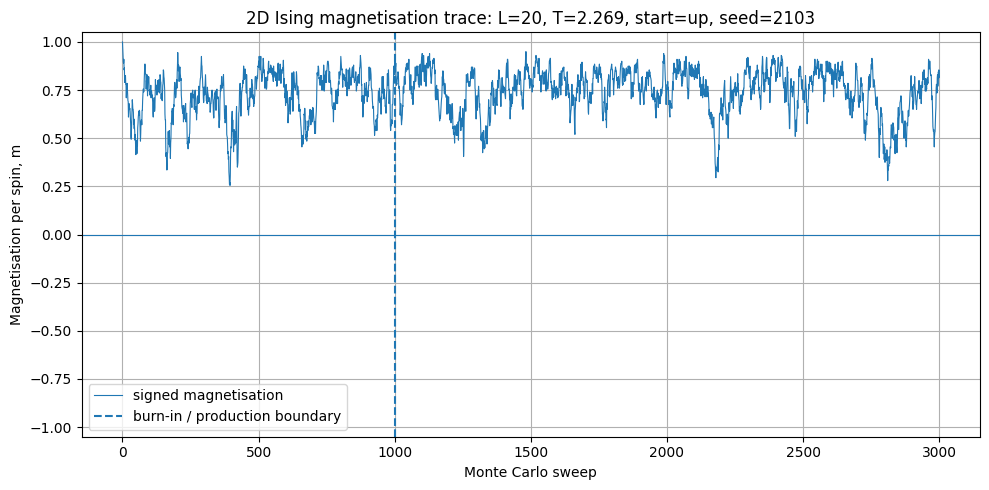

  mean m       = 0.7477
  mean |m|     = 0.7477
  acceptance   = 0.1786
  figure saved = outputs\day21\trace_L20_T2p269_up_seed2103.png
  data saved   = outputs\day21\trace_L20_T2p269_up_seed2103.npz

Running high_ordered...


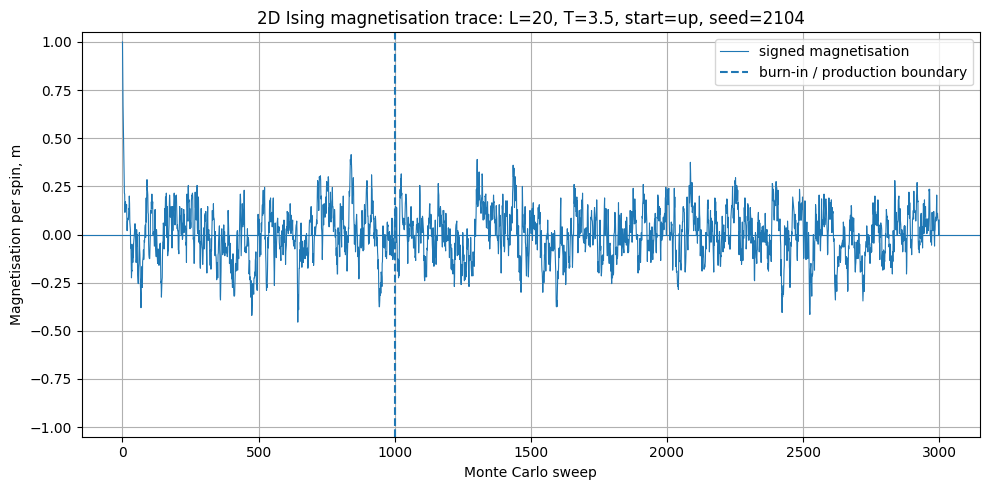

  mean m       = 0.0034
  mean |m|     = 0.0991
  acceptance   = 0.5476
  figure saved = outputs\day21\trace_L20_T3p500_up_seed2104.png
  data saved   = outputs\day21\trace_L20_T3p500_up_seed2104.npz



In [7]:
# Shared parameters keep the comparison controlled across all four runs.
COMMON_PARAMETERS = {
    "L": 20,
    "n_burn_sweeps": 1000,
    "n_production_sweeps": 2000,
    "sample_interval": 5,
}

# Each run has a recorded initial state and a distinct, reproducible seed.
RUN_SPECIFICATIONS = {
    "low_ordered": {
        "T": 1.5,
        "initial_state": "up",
        "seed": 2101,
    },
    "critical_random": {
        "T": 2.269,
        "initial_state": "random",
        "seed": 2102,
    },
    "critical_ordered": {
        "T": 2.269,
        "initial_state": "up",
        "seed": 2103,
    },
    "high_ordered": {
        "T": 3.5,
        "initial_state": "up",
        "seed": 2104,
    },
}

# Store every result dictionary so later tests and statistics use the same raw runs.
runs = {}

for name, specification in RUN_SPECIFICATIONS.items():
    print(f"Running {name}...")

    # Run the full burn-in and production pipeline.
    run = run_magnetisation_trace(
        **COMMON_PARAMETERS,
        **specification,
    )
    runs[name] = run

    # Save both the visual trace and the complete numerical record.
    figure_path = plot_magnetisation_trace(run)
    data_path = save_trace_data(run)

    print(f"  mean m       = {run['mean_m']:.4f}")
    print(f"  mean |m|     = {run['mean_abs_m']:.4f}")
    print(f"  acceptance   = {run['mean_acceptance']:.4f}")
    print(f"  figure saved = {figure_path}")
    print(f"  data saved   = {data_path}")
    print()

## 7. Implementation Tests
**Source:** Krauth, p. 250, warns about factors of two in the Ising energy change and recommends checking small systems before proceeding to larger simulations.

The following assertions check the exact local energy change for known lattices, deterministic reproduction from a fixed seed, valid spin values, valid trace lengths and two basic physical trends.

In [8]:
# Test 1: exact local energy changes on configurations with known answers.
all_up_grid = np.ones((4, 4), dtype=np.int8)
checkerboard_grid = np.fromfunction(
    lambda i, j: np.where((i + j) % 2 == 0, 1, -1),
    (4, 4),
    dtype=int,
).astype(np.int8)

# In an all-up lattice, flipping one spin breaks four aligned bonds: Delta E = +8J.
assert local_energy_change(all_up_grid, 0, 0, J=1.0) == 8.0

# In a checkerboard lattice, flipping one spin repairs four anti-aligned bonds: Delta E = -8J.
assert local_energy_change(checkerboard_grid, 0, 0, J=1.0) == -8.0


# Test 2: the same seed and parameters must reproduce the same complete trajectory.
test_a = run_magnetisation_trace(
    L=8,
    T=2.5,
    n_burn_sweeps=20,
    n_production_sweeps=40,
    sample_interval=4,
    seed=12345,
    initial_state="random",
)

test_b = run_magnetisation_trace(
    L=8,
    T=2.5,
    n_burn_sweeps=20,
    n_production_sweeps=40,
    sample_interval=4,
    seed=12345,
    initial_state="random",
)

assert np.array_equal(test_a["initial_grid"], test_b["initial_grid"])
assert np.array_equal(test_a["burn_m"], test_b["burn_m"])
assert np.array_equal(test_a["production_m"], test_b["production_m"])
assert np.array_equal(
    test_a["production_acceptance"],
    test_b["production_acceptance"],
)


# Test 3: spins and magnetisation must remain in their physical ranges.
assert set(np.unique(test_a["final_grid"])).issubset({-1, 1})
assert np.all(np.abs(test_a["burn_m"]) <= 1.0)
assert np.all(np.abs(test_a["production_m"]) <= 1.0)


# Test 4: the loop must produce the requested number of values.
assert len(test_a["burn_m"]) == 21          # Initial value plus 20 burn-in sweeps.
assert len(test_a["production_m"]) == 40    # One value after every production sweep.
assert len(test_a["saved_m"]) == 10         # Every fourth production value.


# Test 5: every acceptance fraction must lie between zero and one.
assert np.all((test_a["burn_acceptance"] >= 0.0) & (test_a["burn_acceptance"] <= 1.0))
assert np.all(
    (test_a["production_acceptance"] >= 0.0)
    & (test_a["production_acceptance"] <= 1.0)
)


# Test 6: ordered low-temperature behaviour should exceed high-temperature order.
assert runs["low_ordered"]["mean_abs_m"] > runs["high_ordered"]["mean_abs_m"]

# High temperature should accept more energy-raising fluctuations than low temperature.
assert runs["high_ordered"]["mean_acceptance"] > runs["low_ordered"]["mean_acceptance"]

print("All implementation tests passed.")

All implementation tests passed.


## 8. Autocorrelation and Rough Effective Sample Size
**Source:** Krauth, pp. 61–62, Algorithm 1.28 and Fig. 1.40, for the underestimation of error when correlated Markov-chain values are treated as independent; Krauth, p. 251, Fig. 5.15, for the small number of effectively independent magnetisation excursions near criticality.

The autocorrelation calculation below is a diagnostic implementation motivated by those discussions. It estimates

$$\tau_{\mathrm{int}} \approx \frac{1}{2}+\sum_{k>0}\rho(k), \qquad
N_{\mathrm{eff}} \approx \frac{N}{2\tau_{\mathrm{int}}}.$$

The simple first-non-positive truncation rule is not a final uncertainty method. Multiple seeds and correlation-aware blocking or bootstrap analysis will still be required for the dissertation results.

In [9]:
def autocorrelation(
    values: np.ndarray,
    max_lag: int = 200,
) -> np.ndarray:
    """Calculate a simple normalised autocorrelation function."""
    values = np.asarray(values, dtype=float)

    if values.ndim != 1 or values.size < 2:
        raise ValueError(
            "values must be a one-dimensional array with at least two entries."
        )

    if max_lag < 1:
        raise ValueError("max_lag must be at least 1.")

    # A trace of length N can only support lags from 0 to N - 1.
    max_lag = min(max_lag, values.size - 1)

    # Subtract the sample mean before comparing lagged fluctuations.
    centred = values - np.mean(values)
    denominator = np.dot(centred, centred)

    acf = np.full(max_lag + 1, np.nan)
    acf[0] = 1.0

    # A constant trace has zero variance, so non-zero-lag correlations are undefined.
    if denominator == 0.0:
        return acf

    # The common denominator gives a simple biased estimator suitable for diagnostics.
    for lag in range(1, max_lag + 1):
        acf[lag] = np.dot(centred[:-lag], centred[lag:]) / denominator

    return acf


def rough_correlation_diagnostics(
    values: np.ndarray,
    max_lag: int = 200,
) -> dict:
    """Estimate integrated autocorrelation time from the initial positive ACF."""
    acf = autocorrelation(values, max_lag=max_lag)

    if np.isnan(acf[1:]).all():
        return {
            "tau_int_sweeps": np.nan,
            "n_eff": np.nan,
        }

    # Stop the sum at the first non-positive estimated correlation.
    first_non_positive = np.flatnonzero(acf[1:] <= 0.0)

    if first_non_positive.size:
        stop = int(first_non_positive[0] + 1)
    else:
        stop = len(acf)

    tau_int = 0.5 + float(np.nansum(acf[1:stop]))

    # Numerical noise should not produce an estimate below the independent limit 0.5.
    tau_int = max(tau_int, 0.5)
    n_effective = len(values) / (2.0 * tau_int)

    return {
        "tau_int_sweeps": tau_int,
        "n_eff": n_effective,
    }


def count_magnetisation_sector_switches(values: np.ndarray) -> int:
    """Count sign changes after removing exact zero-magnetisation measurements."""
    signs = np.sign(np.asarray(values, dtype=float))
    non_zero_signs = signs[signs != 0.0]

    if non_zero_signs.size < 2:
        return 0

    return int(np.sum(non_zero_signs[1:] != non_zero_signs[:-1]))

## 9. Diagnostic Summary
**Source:** Krauth, p. 251, explains that a very long local-update trajectory near the transition can still contain only a small number of effectively independent magnetisation samples.

The summary reports both the nominal 2,000 production measurements and a rough effective sample count. Sector switches are also counted because a short within-sector autocorrelation time does not prove that the chain has explored both symmetry-related magnetisation sectors.

In [10]:
# Print a compact comparison of the four fixed-temperature trajectories.
header = (
    f"{'run':<18} {'T':>6} {'mean m':>10} {'mean |m|':>10} "
    f"{'accept':>9} {'tau_int':>9} {'N_eff':>9} {'switches':>10}"
)
print(header)
print("-" * len(header))

for name, run in runs.items():
    diagnostics = rough_correlation_diagnostics(
        run["production_m"],
        max_lag=200,
    )
    sector_switches = count_magnetisation_sector_switches(run["production_m"])

    print(
        f"{name:<18} "
        f"{run['T']:>6.3f} "
        f"{run['mean_m']:>10.4f} "
        f"{run['mean_abs_m']:>10.4f} "
        f"{run['mean_acceptance']:>9.4f} "
        f"{diagnostics['tau_int_sweeps']:>9.2f} "
        f"{diagnostics['n_eff']:>9.1f} "
        f"{sector_switches:>10d}"
    )

run                     T     mean m   mean |m|    accept   tau_int     N_eff   switches
----------------------------------------------------------------------------------------
low_ordered         1.500     0.9868     0.9868    0.0130      1.59     629.9          0
critical_random     2.269     0.7357     0.7357    0.1822     14.89      67.1          0
critical_ordered    2.269     0.7477     0.7477    0.1786     27.79      36.0          0
high_ordered        3.500     0.0034     0.0991    0.5476      6.95     143.9        364


## 10. Interpretation of the Executed Output
**Source:** Krauth, pp. 250–252, for the expected ordered, disordered and critical-slowing-down behaviour. The numerical statements below refer to the fixed seeds and parameters used in this notebook.

At $T=1.5$, the production run gives $\langle|m|\rangle=0.9868$ with a low acceptance fraction of $0.0130$. The trace remains close to the all-up state, which is the expected ordered low-temperature behaviour. At $T=3.5$, the signed mean is $0.0034$, $\langle|m|\rangle=0.0991$ and the acceptance fraction is $0.5476$. The trace rapidly loses the ordered initial condition and fluctuates about zero, which is consistent with a disordered phase.

Near the benchmark critical temperature, the random and ordered starts give similar production magnitudes, $0.7357$ and $0.7477$, and larger correlation times than the low-temperature within-sector fluctuations. This supports the correctness of the implementation and shows the expected slowing of local dynamics. However, both near-critical production traces remain in the positive magnetisation sector, so $\langle m\rangle=\langle|m|\rangle$ for these particular runs. This is not a coding error, but it means that the finite zero-field chain has not demonstrated complete mixing between the $+m$ and $-m$ sectors during 2,000 production sweeps.

The outputs are therefore correct as diagnostic traces, but the rough $N_{\mathrm{eff}}$ values are not final error bars. The low-temperature value in particular measures short fluctuations inside one ordered sector and cannot detect an unobserved, much longer tunnelling time. Final boundary and uncertainty estimates should use several independent seeds and a correlation-aware blocking or bootstrap procedure.

## References
**Primary source:** Werner Krauth, *Statistical Mechanics: Algorithms and Computations*.

- pp. 7–9: Markov-chain initial conditions, memory and correlation time.
- pp. 61–62: data bunching and the error plateau for correlated samples.
- p. 250: local Ising Metropolis move, Fig. 5.14 and Algorithm 5.7.
- pp. 251–252: magnetisation trajectories, critical slowing down and ordered/disordered configurations, Figs. 5.15–5.17.